# KBM hypercube growth-rate parity: five settings families vs GS2

How well does each quasi-linear settings family reproduce GS2's linear growth rate on the KBM
Latin-hypercube point databases? Five arms, pooled over the two databases that have a
tail-averaged GS2 reference, dots coloured by ky.

**Reference reduction.** GS2 growth rates come from `pyro_cube_avg` (tail-averaged). The
last-time-point reduction is *not* used: it is wrong by a median 0.15% but a maximum of 3091% on
these databases, and it can flip the sign of a marginal mode. `R4` is excluded for exactly this
reason -- it varies `ntheta`, so its theta grid is ragged, there is nothing to average, and only a
last-time-point reference exists there.

**WIDTH means different things across these arms, and the split is by CODE.** Both TGLF arms
*search* the width (`FIND_WIDTH=.true.`; `WIDTH` is the search's upper bound, not a width any mode
ran at). Both GFTM arms are *fixed*. `find_width` is carried per sample in every cube so this is
readable rather than inferred.

**`v5` also differs in compressional-field treatment** (`USE_BPAR=F`, where `default` and
`gftm_fw174` run `T`) -- visible as `field=2` against `field=3`. That panel is not a single-axis
contrast.

## Imports and settings

Set `GK_DATA_ROOT` in the repository's `local.env`. All scientific choices are visible here.

In [ ]:
from pathlib import Path
import os
import numpy as np
import xarray as xr
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pyrokinetics import Pyro, PyroScan, PyroCube

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "kbm_hypercube_gamma_parity"
data_root = Path(os.environ["GYRO_DATA_OUTPUT"]).expanduser()

run_template = "Runs"
project = "LATIN_HYPERCUBE"
scan_information = "kbm_8d"

# Databases: only those with a tail-averaged GS2 reference. R4 deliberately excluded.
databases = ["SPR-045", "M1"]
gs2_code, gs2_bundle = "GS2", "pyro_cube_avg"
cube_bundle, cube_file = "pyro_cube", "cube.nc"

# The five arms: (label, code, on-disk leaf). Leaf = the registry canonical name.
arms = [
    ("TGLF default",   "TGLF", "default"),
    ("TGLF V5",        "TGLF", "v5"),
    ("GFTM W=1.74",    "GFTM", "gftm_fw174"),
    ("GFTM W=0.4",     "GFTM", "gftm_fw04"),
    ("GFTM m11_new",   "GFTM", "m11_new"),
]

# A pair enters the statistics only if BOTH sides are finite and strictly growing.
gamma_floor = 1e-3

# The 8 sampled hypercube axes, shared by all three KBM databases (recorded, not used here).
scanned_params = ["ky", "q", "shat", "beta", "deuterium_temp_gradient",
                  "electron_temp_gradient", "electron_dens_gradient", "electron_nu"]

## Load data

One cube per (arm, database), plus the GS2 reference per database. Loading is kept separate so
changing a selection or a plot does not reload.

In [9]:
def cube(code, database, leaf, bundle):
    p = data_root / code / run_template / project / database / scan_information
    return xr.open_dataset((p / leaf if leaf else p) / bundle / cube_file)

reference = {db: cube(gs2_code, db, None, gs2_bundle) for db in databases}
model = {(label, db): cube(code, db, leaf, cube_bundle)
         for label, code, leaf in arms for db in databases}

for db, ds in reference.items():
    print(db, "GS2 ref", dict(ds.sizes), "| model dims", dict(model[(arms[0][0], db)].sizes))

SPR-045 GS2 ref {'sample': 300, 'field': 3, 'theta': 321, 'species': 3} | model dims {'sample': 300, 'mode': 4, 'field': 3, 'theta': 289}
M1 GS2 ref {'sample': 300, 'field': 3, 'theta': 521, 'species': 2} | model dims {'sample': 300, 'mode': 4, 'field': 3, 'theta': 289}


## Calculate and select

This is wrong, mode 0 is always dominant mode and the one we care about

In [10]:
def dominant(ds):
    g = ds["growth_rate"]
    return g.isel(mode=0) if "mode" in g.dims else g

def series(ds):
    "growth rate and ky indexed by sample_name"
    g = dominant(ds)
    name = np.asarray(ds["sample_name"].values, dtype=str)
    return (dict(zip(name, np.asarray(g.values, float))),
            dict(zip(name, np.asarray(ds["ky"].values, float))))

ref = {db: series(ds) for db, ds in reference.items()}
mod = {k: series(ds)[0] for k, ds in model.items()}

# Population: samples where GS2 and EVERY arm are finite and strictly growing.
keep = []
for db in databases:
    rg, rky = ref[db]
    for n, gs2 in rg.items():
        vals = [gs2] + [mod[(label, db)].get(n, np.nan) for label, _, _ in arms]
        if all(np.isfinite(v) and v > gamma_floor for v in vals):
            keep.append((db, n, gs2, rky[n]))

gs2_g = np.array([g for _, _, g, _ in keep])
ky = np.array([k for _, _, _, k in keep])
arm_g = {label: np.array([mod[(label, db)][n] for db, n, _, _ in keep]) for label, _, _ in arms}

def metrics(model_g, truth):
    "RMSE and bias in raw units; Pearson r on log10. Same convention as gftm_toolkit scatter."
    return (float(np.sqrt(np.mean((model_g - truth) ** 2))),
            float(np.mean(model_g - truth)),
            float(np.median(np.abs(model_g - truth))),
            float(np.corrcoef(np.log10(model_g), np.log10(truth))[0, 1]))

stats = {label: metrics(arm_g[label], gs2_g) for label, _, _ in arms}
per_db = {db: sum(1 for d, *_ in keep if d == db) for db in databases}
print("n =", len(keep), "paired samples", per_db)
print(f"{'arm':<14}{'RMSE':>9}{'bias':>9}{'medAE':>9}{'r(log10)':>10}")
for label, _, _ in arms:
    r, b, m, c = stats[label]
    print(f"{label:<14}{r:9.3f}{b:9.3f}{m:9.3f}{c:10.2f}")

n = 460 paired samples {'SPR-045': 212, 'M1': 248}
arm                RMSE     bias    medAE  r(log10)
TGLF default      1.060    0.759    0.582      0.46
TGLF V5           0.305    0.024    0.080      0.66
GFTM W=1.74       0.383    0.104    0.105      0.57
GFTM W=0.4        0.415    0.137    0.048      0.70
GFTM m11_new      0.433    0.008    0.153      0.42


## Plot

Log-log, `y=x` in black, dots coloured by ky on one shared `LogNorm` so panels are comparable.

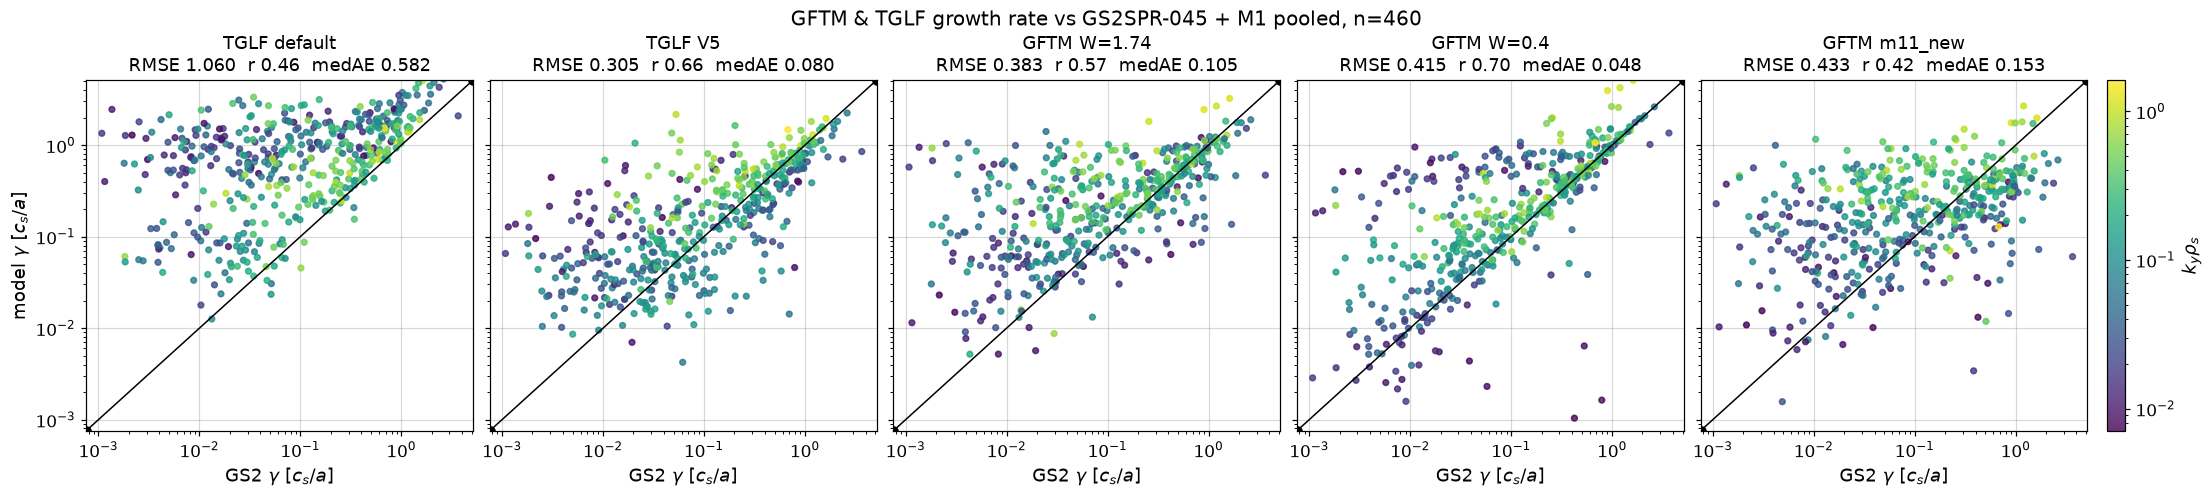

In [11]:
fig, axes = plt.subplots(1, len(arms), figsize=(4 * len(arms), 4.2), sharex=True, sharey=True)
norm, lim = LogNorm(ky.min(), ky.max()), (gs2_g.min() * 0.7, gs2_g.max() * 1.4)

for ax, (label, _, _) in zip(axes, arms):
    r, b, m, c = stats[label]
    s = ax.scatter(gs2_g, arm_g[label], c=ky, norm=norm, cmap="viridis", s=14, alpha=0.8)
    ax.plot(lim, lim, color="black", lw=1)
    ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel=r"GS2 $\gamma$ [$c_s/a$]",
           title=f"{label}\nRMSE {r:.3f}  r {c:.2f}  medAE {m:.3f}")

axes[0].set_ylabel(r"model $\gamma$ [$c_s/a$]")
fig.colorbar(s, ax=axes, label=r"$k_y \rho_s$", pad=0.01)
fig.suptitle(f"GFTM & TGLF growth rate vs GS2"
             f"SPR-045 + M1 pooled, n={len(keep)}", y=1.04)
plt.show()

In [12]:
output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "gamma_parity_five_arms.png", dpi=200, bbox_inches="tight")
print("saved", output_dir / "gamma_parity_five_arms.png")

saved /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis/Plots/kbm_hypercube_gamma_parity/gamma_parity_five_arms.png


saved /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis/Plots/kbm_hypercube_gamma_parity/gamma_parity_five_arms_SPR-045.png


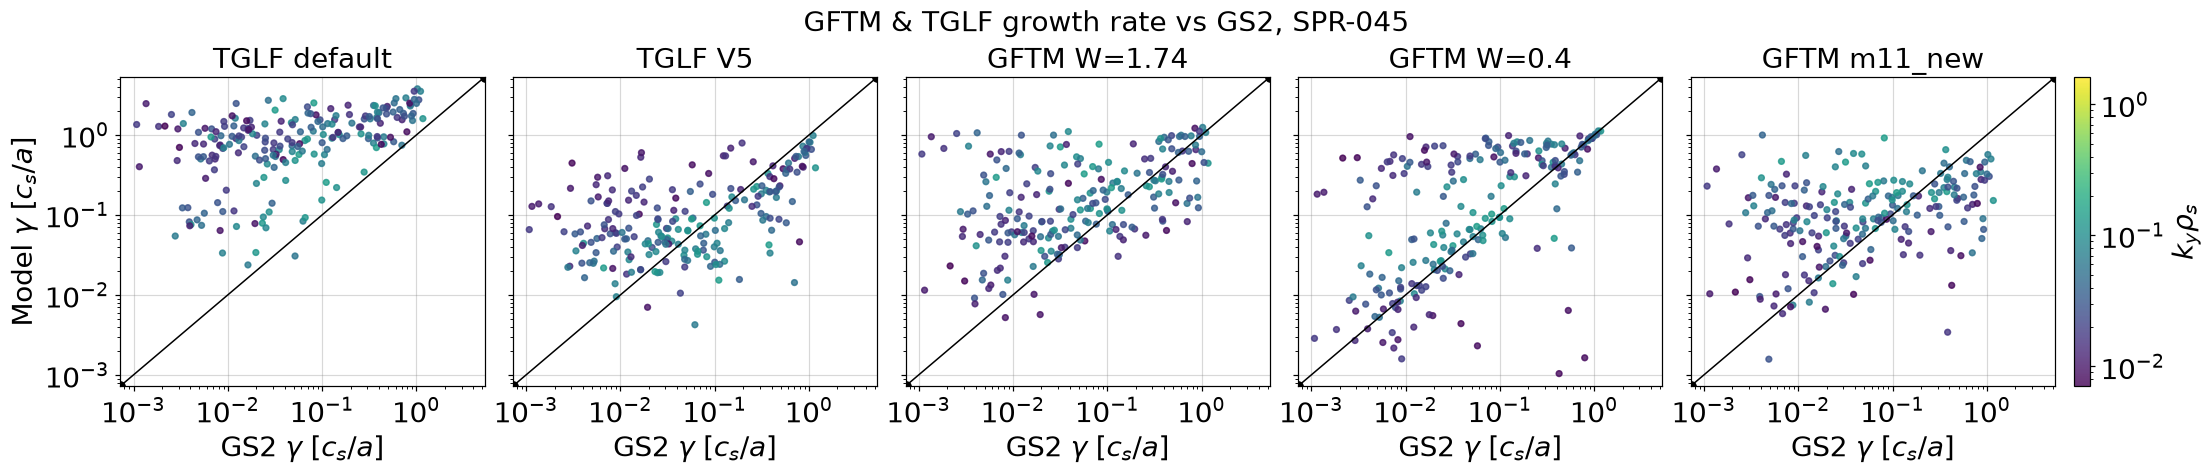

saved /pitagora_work/FUPB2_QLTURB/fwatts/General_Analysis/Plots/kbm_hypercube_gamma_parity/gamma_parity_five_arms_M1.png


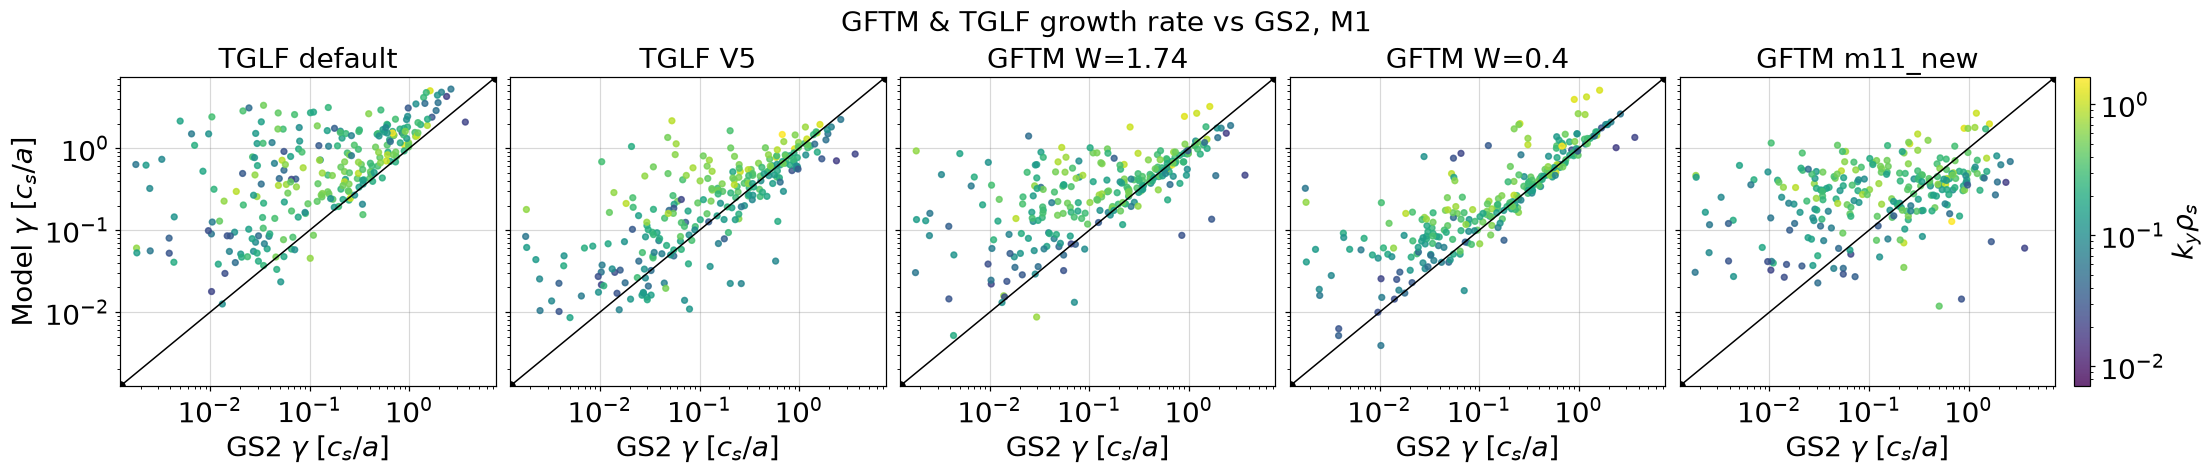

In [13]:
cases = ["SPR-045", "M1"]

output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)

font_sizes = {
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "figure.titlesize": 18,
}

norm = LogNorm(ky.min(), ky.max())

with plt.rc_context(font_sizes):
    for case in cases:
        mask = np.array([d == case for d, *_ in keep])
        if not mask.any():
            continue

        case_gs2 = gs2_g[mask]
        case_ky = ky[mask]
        case_arm = {label: arm_g[label][mask] for label, _, _ in arms}

        values = np.concatenate([case_gs2, *case_arm.values()])
        lim = (values.min() * 0.7, values.max() * 1.4)

        fig, axes = plt.subplots(
            1, len(arms),
            figsize=(4 * len(arms), 4.2),
            sharex=True, sharey=True,
            squeeze=False,
            layout="constrained",
        )
        axes = axes.ravel()

        for ax, (label, _, _) in zip(axes, arms):
            s = ax.scatter(
                case_gs2, case_arm[label],
                c=case_ky, norm=norm, cmap="viridis",
                s=14, alpha=0.8,
            )
            ax.plot(lim, lim, color="black", lw=1)
            ax.set(
                xscale="log", yscale="log",
                xlim=lim, ylim=lim,
                xlabel=r"GS2 $\gamma$ [$c_s/a$]",
                title=label,
            )

        axes[0].set_ylabel(r"Model $\gamma$ [$c_s/a$]")
        fig.colorbar(
            s, ax=axes.tolist(),
            label=r"$k_y \rho_s$", pad=0.01,
        )
        fig.suptitle(f"GFTM & TGLF growth rate vs GS2, {case}")

        output_path = output_dir / f"gamma_parity_five_arms_{case}.png"
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
        print("saved", output_path)

        plt.show()
        plt.close(fig)

In [14]:
import pandas as pd

rows = []

for case in ["SPR-045", "M1"]:
    mask = np.array([d == case for d, *_ in keep])
    if not mask.any():
        continue

    truth = gs2_g[mask]

    for label, _, _ in arms:
        prediction = arm_g[label][mask]

        rmse = np.sqrt(np.mean((prediction - truth) ** 2))

        # Correlation requires at least two samples and nonconstant values.
        x, y = np.log10(truth), np.log10(prediction)
        correlation = (
            np.corrcoef(x, y)[0, 1]
            if len(x) > 1 and np.std(x) > 0 and np.std(y) > 0
            else np.nan
        )

        rows.append({
            "Case": case,
            "Model": label,
            "N": len(truth),
            "RMSE": rmse,
            "Pearson r (log10)": correlation,
        })

results = pd.DataFrame(
    rows, columns=["Case", "Model", "N", "RMSE", "Pearson r (log10)"]
)

display(results.style.format({
    "RMSE": "{:.4f}",
    "Pearson r (log10)": "{:.3f}",
}))

,Case,Model,N,RMSE,Pearson r (log10)
0,SPR-045,TGLF default,212,1.1205,0.452
1,SPR-045,TGLF V5,212,0.1977,0.460
2,SPR-045,GFTM W=1.74,212,0.3150,0.444
3,SPR-045,GFTM W=0.4,212,0.2974,0.565
4,SPR-045,GFTM m11_new,212,0.2749,0.331
5,M1,TGLF default,248,1.0063,0.598
6,M1,TGLF V5,248,0.3724,0.758
7,M1,GFTM W=1.74,248,0.4324,0.633
8,M1,GFTM W=0.4,248,0.4939,0.842
9,M1,GFTM m11_new,248,0.5325,0.362


## Interpretation

Left to the reader. The numbers printed above are the deliverable; the panels differ in more than
one knob at a time (see the header), so a ranking is not a controlled attribution.